#Pytorch Workflow

lest explore a example pytorch end-to-end workflow

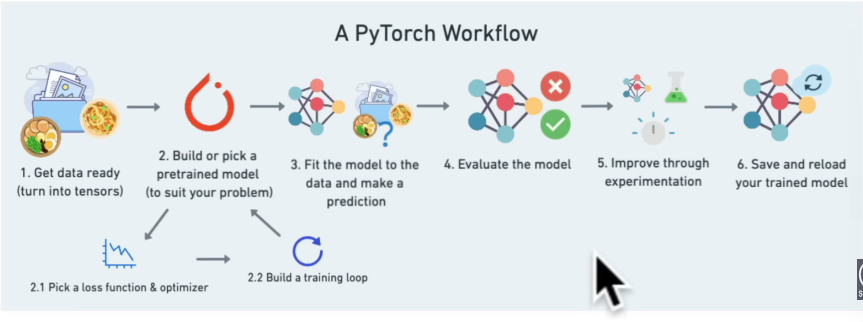

In [20]:
what_were_covering = {1: "data (prepare and load)",
                      2: "build model",
                      3: "fitting the model to data (training)",
                      4: "making predictions and evaluting a model (inference)",
                      5: "saving and loading a model",
                      6: "putting it all together"}

what_were_covering

{1: 'data (prepare and load)',
 2: 'build model',
 3: 'fitting the model to data (training)',
 4: 'making predictions and evaluting a model (inference)',
 5: 'saving and loading a model',
 6: 'putting it all together'}

In [21]:
import torch
from torch import nn #contains all building blocks
import matplotlib.pyplot as plt

torch.__version__

'2.11.0+cpu'

1) Data (preparing and loading)

Data can be almost anything... in machine learning.

    Excel speadsheet
    Images of any kind
    Videos (YouTube has lots of data...)
    Audio like songs or podcasts
    DNA
    Text

Machine learning is a game of two parts:

1. Get data into a numerical representation.
2. Build a model to learn patterns in that numerical representation.

to showcase this , lets create some known data using linear regression formula
We will use a linear regression formula to make a st line with known **parameters**


In [22]:
#Create known parameters

weight = 0.7
bias = 0.3

#create
start=0
end=1
step=0.02
X=torch.arange(start,end,step).unsqueeze(dim=1)
y = weight * X + bias

X[:10],y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [23]:
len(X),len(y)

(50, 50)

### Splitting data into training and test sets (one of the most important concepts...)

Let's create a training and test set with our data.

In [24]:
# Create a train/test split
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [25]:
def plot_prediction(train_data = X_train,
                    train_labels = y_train,
                    test_data = X_test,
                    test_labels = y_test,
                    predictions=None):


 #Plots training data,test data and compare dimesnions

  plt.figure(figsize=(10,7))

 #Plot training data in blue

  plt.scatter(train_data, train_labels,c = 'b',s=4 , label = "Training Data")

 #Plot test data in green
  plt.scatter(test_data, test_labels , c="g",s=4,label="Testing Data")

  #Are there predictions
  if predictions is not None:
    plt.scatter(test_data,predictions,c='red')

  #Show the Legend
  plt.legend(prop={'size':14})




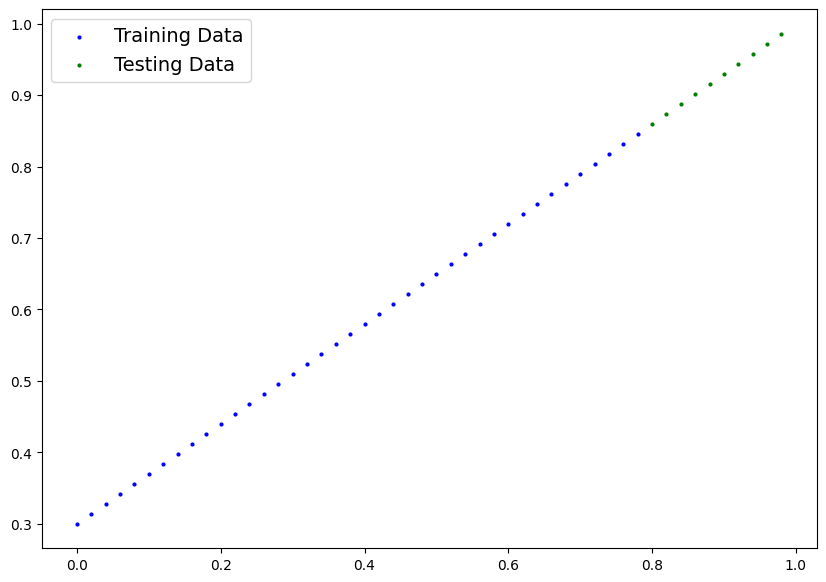

In [26]:
plot_prediction()

First model--
what our model does :
start with random values(weight and bias)
look at the training data and adjust the random values to better represent(or get closer to) the ideal value (the weight & bias value we used to create the data)


how does it do so
two main algorithms-
1) gradient descent
2) backpropagation


In [35]:
import torch
from torch import nn


# Blueprint for our model. Inheriting from nn.Module
class LinearRegressionModel(nn.Module):

   def __init__(self):

        # Let nn.Module run its own setup first
        super().__init__()

        self.weights = nn.Parameter(
            torch.randn(1,                    # one random starting number
                        dtype=torch.float32,  # store it as a 32-bit float
                        requires_grad=True)   # track it so it can learn
        )

        self.bias = nn.Parameter(
            torch.randn(1,                    # one random starting number
                        dtype=torch.float32,  # store it as a 32-bit float
                        requires_grad=True)   # track it so it can learn
        )

   def forward(self, x: torch.Tensor) -> torch.Tensor: #x is the input data

        # The straight-line formula: y = mx + c
        return self.weights * x + self.bias


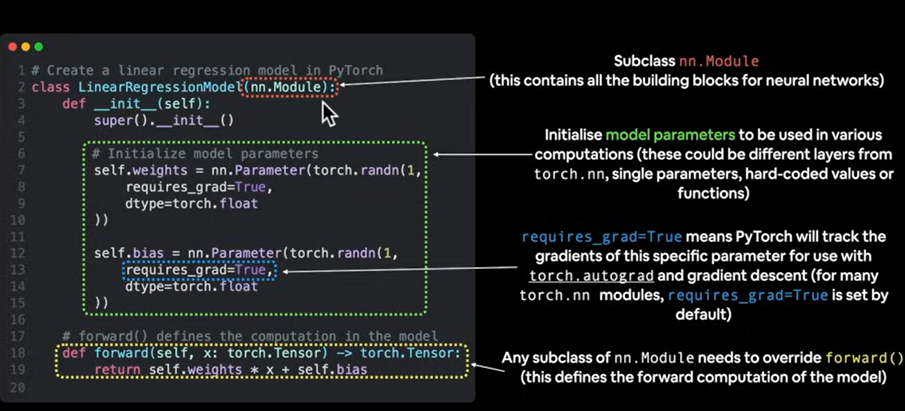

### Python model building essentials

* torch.nn - contains all of the building blocks for computational graphs
(another word for neural networks)

* torch.nn.parameters - what parameter should out model try and learn

* torch.nn.Module -  the abse class for a;; nn modules, if u subclass it,
you should overwrite forward

* torch.optim - this is where the optimizer in pytorch live,help in gradient descent

* def forward() - All nn.module subclass require u to overwrite forward